# Ablation Study Demo Notebook
## Augmented LLM Inference for Bioinformatics Code Generation

> **Purpose:** This notebook walks through every component of the project end-to-end,
> demonstrating what each module does with live, runnable examples.
> No API keys are needed for most sections - the Code Executor and Augmentation Pipeline
> demos are fully self-contained.

---

### Notebook Structure
| Section | What you will see |
|---------|-------------------|
| **1. Setup** | Import modules, configure logging |
| **2. Code Executor** | Watch the sandbox test runner in action with pass/fail examples |
| **3. Augmentation Pipeline** | See all 5 prompt templates rendered for a real problem |
| **4. Model Interface** | Understand the model abstraction layer (API key required to call) |
| **5. Full Mini Experiment** | Run a 4-problem category-backed demo across all 5 conditions |
| **6. Results Visualisation** | Charts of Pass@1, token efficiency, repair convergence |


---
## 1. Setup

Importing the project modules and setting up logging.
Make sure `experiment_runner_patched.py`, `model_interface.py`, `augmentation_pipeline_patched.py`,
and `code_executor.py` are in the same directory as this notebook.


In [4]:
import sys, os, json, textwrap, subprocess, logging, tempfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, HTML, Markdown

# Set up clean logging output for the notebook
logging.basicConfig(level=logging.WARNING)  # suppress INFO spam in demos

# Import project modules
from code_executor import CodeExecutor
from augmentation_pipeline_patched import AugmentationPipeline
from experiment_runner_patched import extract_code
# model_interface and experiment_runner imported in later sections

print('All imports successful')
print(f'Python {sys.version}')


All imports successful
Python 3.11.14 | packaged by conda-forge | (main, Oct 22 2025, 22:35:28) [MSC v.1944 64 bit (AMD64)]


In [7]:
#check code excutor is running properly
import tempfile, os
print(f'Temp directory on this system: {tempfile.gettempdir()}')

# Quick smoke-test: verify CodeExecutor works on this OS
executor = CodeExecutor(timeout=5)
test_code = 'def add(a, b): return a + b'
test_cases = [{'call': 'add(2, 3)', 'expected': 5}]
passed = executor.run_tests(test_code, test_cases)
print(f'CodeExecutor smoke test: {"PASSED" if passed else "FAILED"}') 

Temp directory on this system: C:\Users\hp\AppData\Local\Temp
CodeExecutor smoke test: PASSED


---
## 2. Code Executor — The Sandbox Test Runner

`code_executor.py` is responsible for taking Python code generated by an LLM and
running it against test cases in a completely isolated subprocess. This section
demonstrates every behaviour: passing tests, failing tests, error messages,
timeout enforcement, and the repair feedback loop.

### evaluation pipeline
```
generated_code  →  build_test_script()  →  write /tmp/file.py  →  subprocess.run()  →  pass/fail
```

In [ ]:
# time out condition so that faulty code doesn't run forever, any generated code will run for 5 seconds before being stopped
executor = CodeExecutor(timeout=5)
print('CodeExecutor created with 5s default timeout')

CodeExecutor created with 5s default timeout


### 2.1 — A Correct Implementation (should PASS)

In [9]:
correct_gc = '''
def gc_content(sequence: str) -> float:
    """Return the fraction of G and C bases in a DNA sequence."""
    sequence = sequence.upper()
    if not sequence:
        return 0.0
    gc = sum(1 for base in sequence if base in ('G', 'C'))
    return gc / len(sequence)
'''

tests = [
    {"call": "gc_content('ACGT')",   "expected": 0.5},
    {"call": "gc_content('GGCC')",   "expected": 1.0},
    {"call": "gc_content('AAAA')",   "expected": 0.0},
    {"call": "gc_content('')",       "expected": 0.0},
]

passed, error = executor.run_tests(correct_gc, tests, return_error=True)
status = 'PASSED' if passed else 'FAILED'
print(f'{status}')
if error:
    print(f'Error: {error}')

PASSED


### 2.2 — A Buggy Implementation (should FAIL)

In [10]:
# Bug: only counts G, forgets C
buggy_gc = '''
def gc_content(sequence: str) -> float:
    sequence = sequence.upper()
    return sequence.count('G') / len(sequence) if sequence else 0.0
'''

passed, error = executor.run_tests(buggy_gc, tests, return_error=True)
status = 'PASSED' if passed else 'FAILED'
print(f'{status}')
print(f'Error output that would be sent to repair prompt:')
print('-' * 50)
print(error)

FAILED
Error output that would be sent to repair prompt:
--------------------------------------------------
FAIL test_0: Got 0.25, expected 0.5


### 2.3 — What the Generated Test Script Looks Like

The executor builds a complete Python script internally. Here we show that script
so you can see what gets executed in the subprocess.

In [11]:
script = executor._build_test_script(correct_gc, tests)
print('=' * 60)
print(f'GENERATED TEST SCRIPT (written to {tempfile.gettempdir()}\\tmpXXXXXX.py):',)
print('=' * 60)
print(script)

GENERATED TEST SCRIPT (written to C:\Users\hp\AppData\Local\Temp\tmpXXXXXX.py):
import sys


def gc_content(sequence: str) -> float:
    """Return the fraction of G and C bases in a DNA sequence."""
    sequence = sequence.upper()
    if not sequence:
        return 0.0
    gc = sum(1 for base in sequence if base in ('G', 'C'))
    return gc / len(sequence)


try:
    _result = gc_content('ACGT')
    assert _result == 0.5, "Got " + repr(_result) + ", expected 0.5"
    print('PASS test_0')
except Exception as e:
    print('FAIL test_0: ' + str(e), file=sys.stderr)
    sys.exit(1)
try:
    _result = gc_content('GGCC')
    assert _result == 1.0, "Got " + repr(_result) + ", expected 1.0"
    print('PASS test_1')
except Exception as e:
    print('FAIL test_1: ' + str(e), file=sys.stderr)
    sys.exit(1)
try:
    _result = gc_content('AAAA')
    assert _result == 0.0, "Got " + repr(_result) + ", expected 0.0"
    print('PASS test_2')
except Exception as e:
    print('FAIL test_2: ' + str(e),

### 2.4 — Timeout Enforcement

In [12]:
infinite_loop_code = '''
def gc_content(sequence: str) -> float:
    while True:  # infinite loop bug
        pass
    return 0.0
'''

short_executor = CodeExecutor(timeout=2)
import time
start = time.time()
passed, error = short_executor.run_tests(infinite_loop_code, tests, return_error=True)
elapsed = time.time() - start

print(f'Completed in {elapsed:.1f}s (killed by timeout)')
print(f'Passed: {passed}')
print(f'Error: {error}')

Completed in 2.0s (killed by timeout)
Passed: False
Error: TimeoutError: execution exceeded 2s


### 2.5 — Syntax Error Handling

In [13]:
syntax_error_code = '''
def gc_content(sequence: str) -> float:
    return (sequence.count('G') + sequence.count('C') / len(sequence)
    # missing closing parenthesis
'''

passed, error = executor.run_tests(syntax_error_code, tests, return_error=True)
print(f'Passed: {passed}')
print(f'Error:\n{error}')

Passed: False
Error:
File "C:\Users\hp\AppData\Local\Temp\tmpi4haq3yb.py", line 5
    return (sequence.count('G') + sequence.count('C') / len(sequence)
           ^
SyntaxError: '(' was never closed


---
## 3. Augmentation Pipeline — The 5 Prompt Conditions

This module constructs the prompt sent to the LLM. Each condition adds one more
layer of information. Here we render all five prompts for the same problem
so you can directly compare them.

In [15]:
from pathlib import Path

# Load one real example per dataset category for the notebook demo
DATASET_PATH = Path('biocoder_dataset/python_problems.json')
if not DATASET_PATH.exists():
    raise FileNotFoundError(f'Missing dataset file: {DATASET_PATH}')

with open(DATASET_PATH, encoding='utf-8') as f:
    ALL_DEMO_PROBLEMS = json.load(f)

preferred_ids = ['bc_001', 'bc_021', 'bc_041', 'bc_061']
selected = []
seen_categories = set()
for target_id in preferred_ids:
    match = next((p for p in ALL_DEMO_PROBLEMS if p.get('id') == target_id), None)
    if match and match.get('category') not in seen_categories:
        selected.append(match)
        seen_categories.add(match.get('category'))

for problem in ALL_DEMO_PROBLEMS:
    category = problem.get('category')
    if category not in seen_categories:
        selected.append(problem)
        seen_categories.add(category)

DEMO_POOL = selected
DEMO_PROBLEM = DEMO_POOL[0]

print(f'Loaded {len(DEMO_POOL)} category demo problems from {DATASET_PATH}')
for problem in DEMO_POOL:
    print(f"  - {problem['category']:<18} {problem['id']}  {problem['signature']}")
print()
print('Representative prompt example:', DEMO_PROBLEM['signature'])


Loaded 4 category demo problems from biocoder_dataset\python_problems.json
  - sequence_analysis  bc_001  def gc_content(sequence: str) -> float:
  - protein_analysis   bc_021  def translate_codon(codon: str) -> str:
  - sequence_utils     bc_041  def parse_fasta_string(fasta: str) -> dict:
  - statistics         bc_061  def mean(values: list) -> float:

Representative prompt example: def gc_content(sequence: str) -> float:


In [16]:
CONDITIONS = [
    ('C1_zero_shot',        '🔵 C1 — Zero-Shot Baseline'),
    ('C2_few_shot',         '🟡 C2 — Few-Shot Examples'),
    ('C3_chain_of_thought', '🟠 C3 — Chain-of-Thought'),
    ('C4_rag_context',      '🟣 C4 — RAG Context'),
    ('C5_iterative_repair', '🔴 C5 — Iterative Repair (initial prompt)'),
]

for cond_key, label in CONDITIONS:
    pipeline = AugmentationPipeline(cond_key)
    result = pipeline.generate_prompt(
        problem=DEMO_PROBLEM,
        model='demo',
        all_problems=DEMO_POOL
    )
    prompt = result['prompt']
    print('=' * 70)
    print(f'{label}')
    print(f'Prompt length: {len(prompt)} chars | ~{len(prompt.split())} words')
    print('-' * 70)
    print(prompt[:800] + ('...[truncated]' if len(prompt) > 800 else ''))
    print()

🔵 C1 — Zero-Shot Baseline
Prompt length: 277 chars | ~40 words
----------------------------------------------------------------------
Complete the following Python function for bioinformatics.

def gc_content(sequence: str) -> float:
    """Calculate the GC content of a DNA sequence as a fraction between 0.0 and 1.0. Return 0.0 for empty sequences."""

Provide only the complete function code, no explanation.

🟡 C2 — Few-Shot Examples
Prompt length: 1043 chars | ~148 words
----------------------------------------------------------------------
Here are examples of bioinformatics Python functions:

Example 1:
```python
def gc_content(sequence: str) -> float:
    sequence = sequence.upper()
    gc = sum(1 for base in sequence if base in ('G', 'C'))
    return gc / len(sequence) if sequence else 0.0
```

Example 2:
```python
def reverse_complement(dna: str) -> str:
    complement = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C'}
    return ''.join(complement.get(b.upper(), 'N') for b in reversed(d

c:\Users\hp\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8747.86it/s]


🟣 C4 — RAG Context
Prompt length: 2208 chars | ~195 words
----------------------------------------------------------------------
Use the following context to help implement the function:


# Relevant BioPython / Bioinformatics API Context
## Sequence Handling
- `Bio.Seq.Seq(sequence)` — creates a sequence object; supports `.complement()`, `.reverse_complement()`, `.translate()`
- `str.count(sub)` — useful for counting nucleotide occurrences
- `collections.Counter` — efficient frequency counting for k-mer analysis
## Common Patterns
- GC content: `(seq.count('G') + seq.count('C')) / len(seq)`
- Hamming distance: `sum(a != b for a, b in zip(s1, s2))`
- Smith-Waterman: use `Bio.pairwise2.align.localms` for local alignment
- FASTA parsing: `Bio.SeqIO.parse(handle, 'fasta')`


## Similar Functions from Dataset
Similar function 1:
```python
def translate_codon(codon: str) -> str:
    table = {'UUU':'F','UUC':'F','UUA':'L'...[truncated]

🔴 C5 — Iterative Repair (initial prompt)
Prompt length:

### 3.1 — Prompt Length Comparison Across Conditions

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2344.38it/s]


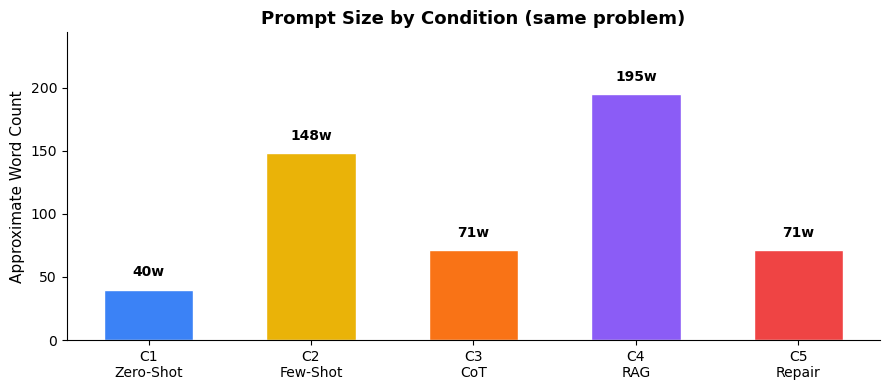

Note: RAG is largest due to API context block + 3 retrieved examples


In [17]:
import matplotlib.pyplot as plt

cond_labels = ['C1\nZero-Shot', 'C2\nFew-Shot', 'C3\nCoT', 'C4\nRAG', 'C5\nRepair']
lengths = []
for cond_key, _ in CONDITIONS:
    p = AugmentationPipeline(cond_key)
    r = p.generate_prompt(problem=DEMO_PROBLEM, all_problems=DEMO_POOL)
    lengths.append(len(r['prompt'].split()))

colors = ['#3B82F6','#EAB308','#F97316','#8B5CF6','#EF4444']
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(cond_labels, lengths, color=colors, width=0.55, edgecolor='white')
ax.set_ylabel('Approximate Word Count', fontsize=11)
ax.set_title('Prompt Size by Condition (same problem)', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(lengths) * 1.25)
for bar, val in zip(bars, lengths):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'{val}w', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
print('Note: RAG is largest due to API context block + 3 retrieved examples')

---
## 4. Full Mini Experiment - End-to-End Demo (Mocked)

This section demonstrates the entire experiment flow on 4 problems,
one from each dataset category, without any API keys. A mock model is used
that returns pre-written correct or buggy code based on the condition, so
you can see every stage of the pipeline working together.


In [19]:
# Mock model that simulates different behaviour per condition

MOCK_SOLUTIONS = {
    'gc_content': {
        'correct': '''def gc_content(sequence: str) -> float:
    sequence = sequence.upper()
    if not sequence:
        return 0.0
    return (sequence.count('G') + sequence.count('C')) / len(sequence)''',
        'buggy': '''def gc_content(sequence: str) -> float:
    if not sequence:
        return 0.0
    return sequence.count('G') / len(sequence)  # bug: forgot C'''
    },
    'translate_codon': {
        'correct': '''def translate_codon(codon: str) -> str:
    table = {'UUU':'F','UUC':'F','UUA':'L','UUG':'L','CUU':'L','CUC':'L','CUA':'L','CUG':'L','AUU':'I','AUC':'I','AUA':'I','AUG':'M','GUU':'V','GUC':'V','GUA':'V','GUG':'V','UCU':'S','UCC':'S','UCA':'S','UCG':'S','CCU':'P','CCC':'P','CCA':'P','CCG':'P','ACU':'T','ACC':'T','ACA':'T','ACG':'T','GCU':'A','GCC':'A','GCA':'A','GCG':'A','UAU':'Y','UAC':'Y','UAA':'*','UAG':'*','CAU':'H','CAC':'H','CAA':'Q','CAG':'Q','AAU':'N','AAC':'N','AAA':'K','AAG':'K','GAU':'D','GAC':'D','GAA':'E','GAG':'E','UGU':'C','UGC':'C','UGA':'*','UGG':'W','CGU':'R','CGC':'R','CGA':'R','CGG':'R','AGU':'S','AGC':'S','AGA':'R','AGG':'R','GGU':'G','GGC':'G','GGA':'G','GGG':'G'}
    return table.get(codon.upper(), 'X')''',
        'buggy': '''def translate_codon(codon: str) -> str:
    return 'X'  # bug: ignores the codon table'''
    },
    'parse_fasta_string': {
        'correct': '''def parse_fasta_string(fasta: str) -> dict:
    result = {}
    current_id = None
    for line in fasta.strip().splitlines():
        line = line.strip()
        if line.startswith('>'):
            current_id = line[1:].split()[0]
            result[current_id] = ''
        elif current_id:
            result[current_id] += line
    return result''',
        'buggy': '''def parse_fasta_string(fasta: str) -> dict:
    return {}  # bug: never parses any records'''
    },
    'mean': {
        'correct': '''def mean(values: list) -> float:
    if not values:
        return 0.0
    return sum(values) / len(values)''',
        'buggy': '''def mean(values: list) -> float:
    return sum(values)  # bug: forgot to divide by length'''
    },
}

class MockModelInterface:
    'Simulates condition-sensitive behavior with reasoning-heavy outputs.'
    def __init__(self, name='mock_model'):
        self.name = name
        self.call_count = 0

    def generate(self, prompt: str, max_tokens: int = 2048):
        self.call_count += 1
        prompt_lower = prompt.lower()

        import re

        fn_name = 'gc_content'
        fn_matches = re.findall(r"def\s+([A-Za-z_]\w*)\s*\(", prompt)
        if fn_matches:
            fn_name = fn_matches[-1]

        if '[c5 initial attempt]' in prompt_lower:
            code = MOCK_SOLUTIONS[fn_name]['buggy']
            text = f"First repair attempt reasoning.\n\n{code}\n\nThis version is still wrong."
        elif 'diagnose' in prompt_lower or 'fix this code' in prompt_lower:
            code = MOCK_SOLUTIONS[fn_name]['correct']
            text = f"Repair reasoning.\n\n{code}\n\nFixed."
        elif 'use the following context' in prompt_lower:
            code = MOCK_SOLUTIONS[fn_name]['correct']
            text = f"Retrieved context points to the right implementation.\n\n{code}\n\nDone."
        elif 'step by step' in prompt_lower:
            code = MOCK_SOLUTIONS[fn_name]['correct']
            text = f"Reasoning first.\n\n{code}\n\nDone."
        else:
            code = MOCK_SOLUTIONS[fn_name]['buggy']
            text = code

        return {
            'text': text,
            'prompt_tokens': len(prompt.split()),
            'completion_tokens': len(text.split()),
        }

print('MockModelInterface defined')


MockModelInterface defined


In [20]:
# One demo problem per dataset category

DEMO_PROBLEMS = DEMO_POOL
print(f'{len(DEMO_PROBLEMS)} demo problems loaded')
for problem in DEMO_PROBLEMS:
    print(f"  - {problem['category']:<18} {problem['id']}  {problem['signature']}")


4 demo problems loaded
  - sequence_analysis  bc_001  def gc_content(sequence: str) -> float:
  - protein_analysis   bc_021  def translate_codon(codon: str) -> str:
  - sequence_utils     bc_041  def parse_fasta_string(fasta: str) -> dict:
  - statistics         bc_061  def mean(values: list) -> float:


In [21]:
# Run the mini experiment

CONDITIONS_DEMO = [
    'C1_zero_shot',
    'C2_few_shot',
    'C3_chain_of_thought',
    'C4_rag_context',
    'C5_iterative_repair',
]

executor = CodeExecutor(timeout=5)
mock_model = MockModelInterface()

results_table = []

print(f'Running mini experiment: {len(CONDITIONS_DEMO)} conditions x {len(DEMO_PROBLEMS)} problems\n')

for condition in CONDITIONS_DEMO:
    pipeline = AugmentationPipeline(condition)
    cond_passed = 0
    print(f'  Condition: {condition}')

    for problem in DEMO_PROBLEMS:
        prompt_data = pipeline.generate_prompt(problem=problem, all_problems=DEMO_PROBLEMS)
        model_prompt = prompt_data['prompt']
        if condition == 'C5_iterative_repair':
            model_prompt = '[C5 initial attempt]\n\n' + model_prompt

        response = mock_model.generate(model_prompt)
        generated_code = extract_code(response['text'])
        attempts = 1

        if condition == 'C5_iterative_repair':
            passed_first, error = executor.run_tests(generated_code, problem['tests'], return_error=True)
            if not passed_first:
                repair_prompt = (
                    f'The code failed:\n{error}\n\n'
                    f'Task: {problem["docstring"]}\n\n'
                    f'Fix this code:\n```python\n{generated_code}\n```\n\nDiagnose and fix.'
                )
                repair_response = mock_model.generate(repair_prompt)
                generated_code = extract_code(repair_response['text'])
                attempts = 2

        test_passed = executor.run_tests(generated_code, problem['tests'])
        cond_passed += int(test_passed)
        results_table.append({
            'condition': condition,
            'problem_id': problem['id'],
            'category': problem['category'],
            'passed': test_passed,
            'attempts': attempts,
            'prompt_tokens': response['prompt_tokens'],
            'completion_tokens': response['completion_tokens'],
        })
        symbol = 'PASS' if test_passed else 'FAIL'
        print(f"    {symbol:<4} {problem['category']:<18} {problem['id']:<8} attempts={attempts}")

    pass_pct = 100 * cond_passed / len(DEMO_PROBLEMS)
    label = 'FinalPass' if condition == 'C5_iterative_repair' else 'Pass@1'
    print(f'    {label} = {pass_pct:.0f}% ({cond_passed}/{len(DEMO_PROBLEMS)})\n')


Running mini experiment: 5 conditions x 4 problems

  Condition: C1_zero_shot
    FAIL sequence_analysis  bc_001   attempts=1
    FAIL protein_analysis   bc_021   attempts=1
    FAIL sequence_utils     bc_041   attempts=1
    FAIL statistics         bc_061   attempts=1
    Pass@1 = 0% (0/4)

  Condition: C2_few_shot
    FAIL sequence_analysis  bc_001   attempts=1
    FAIL protein_analysis   bc_021   attempts=1
    FAIL sequence_utils     bc_041   attempts=1
    FAIL statistics         bc_061   attempts=1
    Pass@1 = 0% (0/4)

  Condition: C3_chain_of_thought
    PASS sequence_analysis  bc_001   attempts=1
    PASS protein_analysis   bc_021   attempts=1
    PASS sequence_utils     bc_041   attempts=1
    PASS statistics         bc_061   attempts=1
    Pass@1 = 100% (4/4)

  Condition: C4_rag_context


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4100.98it/s]


    PASS sequence_analysis  bc_001   attempts=1
    PASS protein_analysis   bc_021   attempts=1
    PASS sequence_utils     bc_041   attempts=1
    PASS statistics         bc_061   attempts=1
    Pass@1 = 100% (4/4)

  Condition: C5_iterative_repair
    PASS sequence_analysis  bc_001   attempts=2
    PASS protein_analysis   bc_021   attempts=2
    PASS sequence_utils     bc_041   attempts=2
    PASS statistics         bc_061   attempts=2
    FinalPass = 100% (4/4)



---
## 6. Results Visualisation

Charts showing the mini-experiment results. These same charts would be generated
from your real 5-model × 5-condition results using the same code.

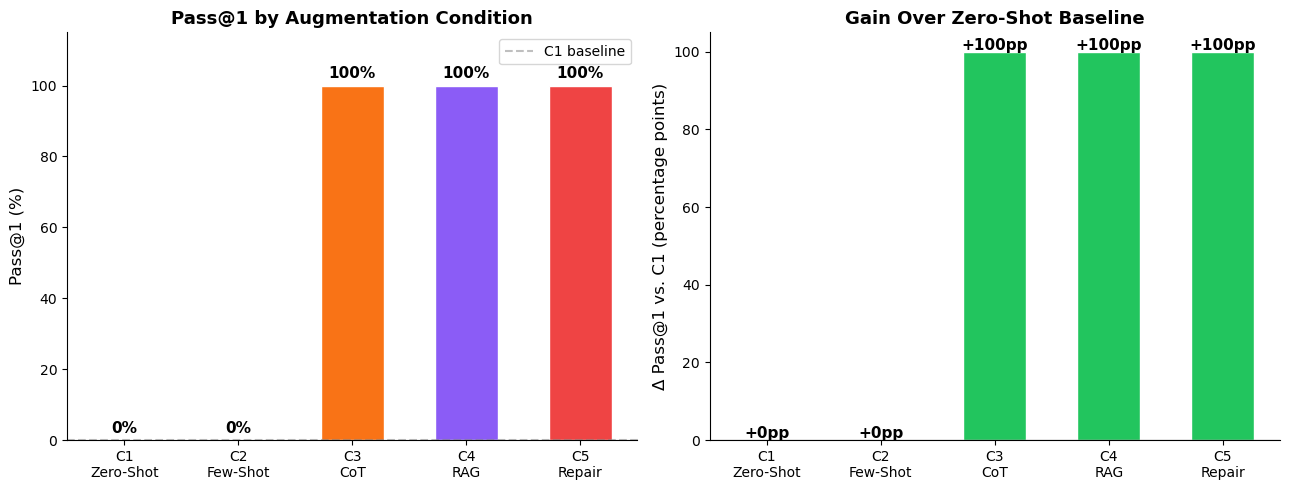

In [22]:
# Compute pass rates per condition
cond_pass = {}
for row in results_table:
    c = row['condition']
    cond_pass.setdefault(c, []).append(row['passed'])

pass_rates = {c: 100 * sum(v) / len(v) for c, v in cond_pass.items()}
short_labels = ['C1\nZero-Shot', 'C2\nFew-Shot', 'C3\nCoT', 'C4\nRAG', 'C5\nRepair']
rates = [pass_rates.get(c, 0) for c in CONDITIONS_DEMO]

# Delta (gain over C1)
deltas = [r - rates[0] for r in rates]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Chart 1: Absolute Pass@1
colors = ['#3B82F6','#EAB308','#F97316','#8B5CF6','#EF4444']
axes[0].bar(short_labels, rates, color=colors, width=0.55, edgecolor='white')
axes[0].set_ylabel('Pass@1 (%)', fontsize=12)
axes[0].set_title('Pass@1 by Augmentation Condition', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 115)
axes[0].axhline(rates[0], color='gray', linestyle='--', alpha=0.5, label='C1 baseline')
axes[0].legend(fontsize=10)
for i, (bar, val) in enumerate(zip(axes[0].patches, rates)):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                 f'{val:.0f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Chart 2: Gains over baseline
delta_colors = ['#94A3B8' if d <= 0 else '#22C55E' for d in deltas]
axes[1].bar(short_labels, deltas, color=delta_colors, width=0.55, edgecolor='white')
axes[1].set_ylabel('Δ Pass@1 vs. C1 (percentage points)', fontsize=12)
axes[1].set_title('Gain Over Zero-Shot Baseline', fontsize=13, fontweight='bold')
axes[1].axhline(0, color='black', linewidth=0.8)
for i, (bar, val) in enumerate(zip(axes[1].patches, deltas)):
    ypos = val + 0.5 if val >= 0 else val - 2.5
    axes[1].text(bar.get_x()+bar.get_width()/2, ypos,
                 f'{val:+.0f}pp', ha='center', fontsize=11, fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

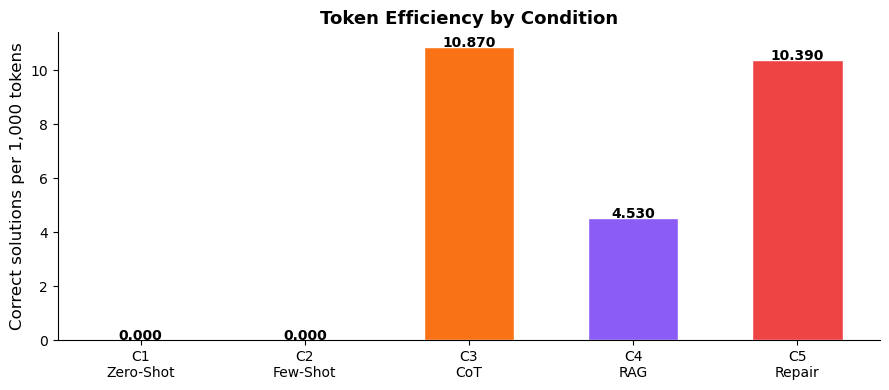

Interpretation: higher = more correct solutions per token spent (cost efficiency)


In [23]:
# Token efficiency per condition
cond_tokens = {}
cond_correct = {}
for row in results_table:
    c = row['condition']
    cond_tokens.setdefault(c, 0)
    cond_correct.setdefault(c, 0)
    cond_tokens[c] += row['prompt_tokens'] + row['completion_tokens']
    cond_correct[c] += int(row['passed'])

efficiencies = {c: (cond_correct[c] * 1000) / cond_tokens[c] if cond_tokens[c] else 0
                for c in CONDITIONS_DEMO}
eff_vals = [efficiencies.get(c, 0) for c in CONDITIONS_DEMO]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(short_labels, eff_vals, color=colors, width=0.55, edgecolor='white')
ax.set_ylabel('Correct solutions per 1,000 tokens', fontsize=12)
ax.set_title('Token Efficiency by Condition', fontsize=13, fontweight='bold')
for bar, val in zip(ax.patches, eff_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
print('Interpretation: higher = more correct solutions per token spent (cost efficiency)')